In [1]:
# Local environment setup
from pathlib import Path

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import gradio as gr

# Safe device detection (CPU / GPU compatibility)
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    print("GPU available:", gpus)
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass
else:
    print("GPU not available. Using CPU.")

GPU not available. Using CPU.


In [3]:
from pathlib import Path

DATASET_PATH = Path("household_power_consumption.txt")
if not DATASET_PATH.exists() and (Path("FRANCE_DATASET") / "household_power_consumption.txt").exists():
    DATASET_PATH = Path("FRANCE_DATASET") / "household_power_consumption.txt"

file_path = DATASET_PATH

df = pd.read_csv(
    file_path,
    sep=';',
    header=None
)

print("Original dataset shape:", df.shape)

df.head()

C:\Users\Dell\AppData\Local\Temp\ipykernel_24712\1616290886.py:9: DtypeWarning: Columns (0: 2, 1: 3, 2: 4, 3: 5, 4: 6, 5: 7, 6: 8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


Original dataset shape: (2075260, 9)


,0,1,2,3,4,5,6,7,8
0,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
1,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.000
2,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.000
3,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.000
4,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.000


In [4]:
df.columns = [
    'Date',
    'Time',
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

print(df.head())

         Date      Time  Global_active_power  Global_reactive_power  Voltage  \
0        Date      Time  Global_active_power  Global_reactive_power  Voltage   
1  16/12/2006  17:24:00                4.216                  0.418  234.840   
2  16/12/2006  17:25:00                5.360                  0.436  233.630   
3  16/12/2006  17:26:00                5.374                  0.498  233.290   
4  16/12/2006  17:27:00                5.388                  0.502  233.740   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
0  Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
1            18.400           0.000           1.000          17.000  
2            23.000           0.000           1.000          16.000  
3            23.000           0.000           2.000          17.000  
4            23.000           0.000           1.000          17.000  


In [5]:
df = df.replace('?', np.nan)

print("Missing values:")
print(df.isnull().sum())

Missing values:
Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64


In [6]:
df['Global_active_power'] = pd.to_numeric(
    df['Global_active_power'],
    errors='coerce'
)

print(df['Global_active_power'].dtype)

float64


In [7]:
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    format='%d/%m/%Y %H:%M:%S',
    errors='coerce'
)

print(df[['Datetime', 'Global_active_power']].head())

             Datetime  Global_active_power
0                 NaT                  NaN
1 2006-12-16 17:24:00                4.216
2 2006-12-16 17:25:00                5.360
3 2006-12-16 17:26:00                5.374
4 2006-12-16 17:27:00                5.388


In [8]:
df = df[
    ['Datetime', 'Global_active_power']
].dropna()

print("Shape after cleaning:", df.shape)

Shape after cleaning: (2049280, 2)


In [9]:
df = df.sort_values(
    'Datetime'
).reset_index(drop=True)

print("First datetime:", df['Datetime'].iloc[0])
print("Last datetime:", df['Datetime'].iloc[-1])

First datetime: 2006-12-16 17:24:00
Last datetime: 2010-11-26 21:02:00


In [10]:
print(df.head())
print()
print(df.tail())
print()
print("Total observations:", len(df))

             Datetime  Global_active_power
0 2006-12-16 17:24:00                4.216
1 2006-12-16 17:25:00                5.360
2 2006-12-16 17:26:00                5.374
3 2006-12-16 17:27:00                5.388
4 2006-12-16 17:28:00                3.666

                   Datetime  Global_active_power
2049275 2010-11-26 20:58:00                0.946
2049276 2010-11-26 20:59:00                0.944
2049277 2010-11-26 21:00:00                0.938
2049278 2010-11-26 21:01:00                0.934
2049279 2010-11-26 21:02:00                0.932

Total observations: 2049280


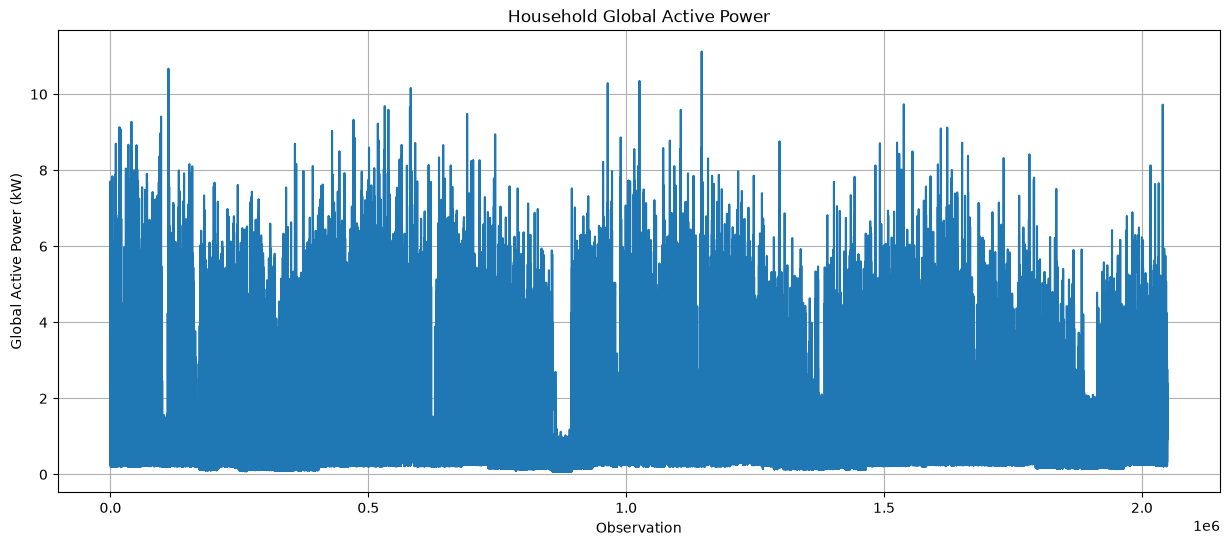

In [11]:
plt.figure(figsize=(15, 6))

plt.plot(
    df['Global_active_power']
)

plt.title(
    'Household Global Active Power'
)

plt.xlabel('Observation')

plt.ylabel(
    'Global Active Power (kW)'
)

plt.grid(True)

plt.show()

In [12]:
power = df[
    'Global_active_power'
].values.reshape(-1, 1)

print("Power shape:", power.shape)

Power shape: (2049280, 1)


In [13]:
split_index = int(
    len(power) * 0.8
)

train_power = power[:split_index]

test_power = power[split_index:]

print("Training observations:", len(train_power))
print("Testing observations:", len(test_power))

Training observations: 1639424
Testing observations: 409856


In [14]:
scaler = MinMaxScaler(
    feature_range=(0, 1)
)

train_scaled = scaler.fit_transform(
    train_power
)

test_scaled = scaler.transform(
    test_power
)

print("Scaling completed.")

Scaling completed.


In [15]:
SEQUENCE_LENGTH = 60

print(
    "Sequence length:",
    SEQUENCE_LENGTH
)

Sequence length: 60


In [16]:
BATCH_SIZE = 256

train_dataset = tf.keras.utils.timeseries_dataset_from_array(
    data=train_scaled,
    targets=train_scaled[SEQUENCE_LENGTH:],
    sequence_length=SEQUENCE_LENGTH,
    sequence_stride=1,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_dataset = tf.keras.utils.timeseries_dataset_from_array(
    data=test_scaled,
    targets=test_scaled[SEQUENCE_LENGTH:],
    sequence_length=SEQUENCE_LENGTH,
    sequence_stride=1,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train dataset created.")
print("Test dataset created.")

Train dataset created.
Test dataset created.


In [17]:
for X_batch, y_batch in train_dataset.take(1):

    print(
        "X batch shape:",
        X_batch.shape
    )

    print(
        "y batch shape:",
        y_batch.shape
    )

X batch shape: (256, 60, 1)
y batch shape: (256, 1)


In [18]:
lstm_model = Sequential([

    LSTM(
        50,
        input_shape=(
            SEQUENCE_LENGTH,
            1
        )
    ),

    Dropout(0.2),

    Dense(25, activation='relu'),

    Dense(1)
])

lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

lstm_model.summary()

c:\Users\Dell\AppData\Local\Programs\Python\Python314\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,701 (45.71 KB)

 Trainable params: 11,701 (45.71 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [20]:
history = lstm_model.fit(
    train_dataset,
    epochs=10,
    validation_data=test_dataset,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/10


c:\Users\Dell\AppData\Local\Programs\Python\Python314\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


6404/6404 ━━━━━━━━━━━━━━━━━━━━ 432s 67ms/step - loss: 7.8321e-04 - val_loss: 4.3103e-04
Epoch 2/10
6404/6404 ━━━━━━━━━━━━━━━━━━━━ 435s 68ms/step - loss: 6.4535e-04 - val_loss: 4.4872e-04
Epoch 3/10
6404/6404 ━━━━━━━━━━━━━━━━━━━━ 437s 68ms/step - loss: 6.2725e-04 - val_loss: 4.6190e-04
Epoch 4/10
6404/6404 ━━━━━━━━━━━━━━━━━━━━ 442s 69ms/step - loss: 6.1821e-04 - val_loss: 4.7580e-04


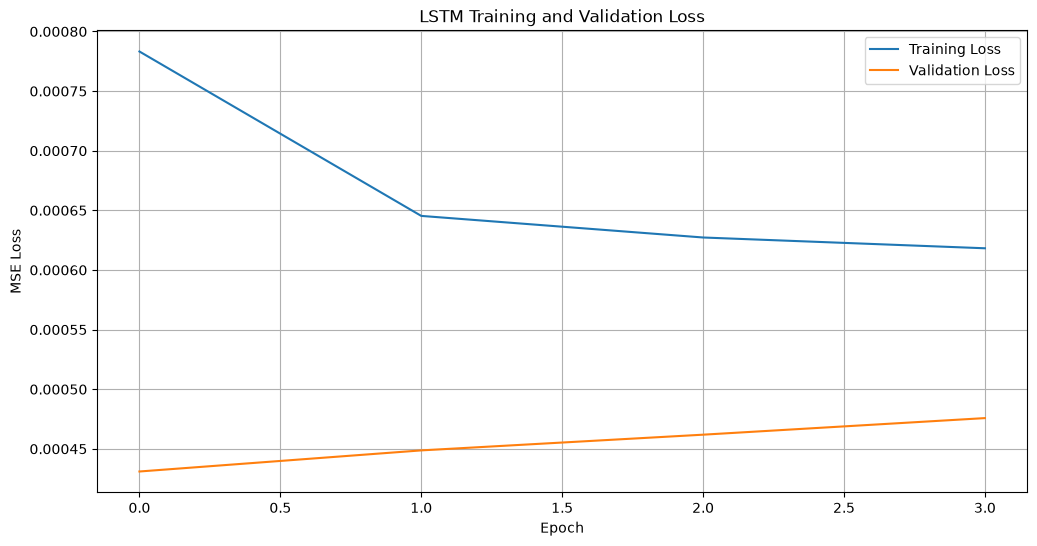

In [21]:
plt.figure(figsize=(12, 6))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title(
    'LSTM Training and Validation Loss'
)

plt.xlabel('Epoch')

plt.ylabel('MSE Loss')

plt.legend()

plt.grid(True)

plt.show()

In [22]:
print("Generating predictions...")

pred_scaled = lstm_model.predict(
    test_dataset,
    verbose=1
)

print(
    "Prediction shape:",
    pred_scaled.shape
)

Generating predictions...
1601/1601 ━━━━━━━━━━━━━━━━━━━━ 44s 27ms/step
Prediction shape: (409796, 1)


In [23]:
actual_scaled = []

for X_batch, y_batch in test_dataset:

    actual_scaled.append(
        y_batch.numpy()
    )

actual_scaled = np.concatenate(
    actual_scaled
)

print(
    "Actual shape:",
    actual_scaled.shape
)

Actual shape: (409796, 1)


In [24]:
y_pred = scaler.inverse_transform(
    pred_scaled
).flatten()

y_actual = scaler.inverse_transform(
    actual_scaled
).flatten()

print("First 10 actual values:")
print(y_actual[:10])

print()

print("First 10 predicted values:")
print(y_pred[:10])

First 10 actual values:
[0.876 0.864 0.858 0.856 0.254 0.276 0.274 0.27  0.268 0.272]

First 10 predicted values:
[0.6617559  0.79188037 0.7649732  0.7606928  0.7642738  0.20221186
 0.22631386 0.22262044 0.21819791 0.21938518]


In [25]:
lstm_mae = mean_absolute_error(
    y_actual,
    y_pred
)

lstm_mse = mean_squared_error(
    y_actual,
    y_pred
)

lstm_rmse = np.sqrt(
    lstm_mse
)

lstm_r2 = r2_score(
    y_actual,
    y_pred
)

print("\n========== LSTM RESULTS ==========")

print(
    f"MAE  : {lstm_mae:.4f}"
)

print(
    f"MSE  : {lstm_mse:.4f}"
)

print(
    f"RMSE : {lstm_rmse:.4f}"
)

print(
    f"R²   : {lstm_r2:.4f}"
)


========== LSTM RESULTS ==========
MAE  : 0.1145
MSE  : 0.0526
RMSE : 0.2293
R²   : 0.9345


In [26]:
lstm_results = {
    'Model': 'LSTM',
    'MAE': lstm_mae,
    'MSE': lstm_mse,
    'RMSE': lstm_rmse,
    'R2': lstm_r2
}

print(lstm_results)

{'Model': 'LSTM', 'MAE': 0.11451434797459231, 'MSE': 0.052591205474580294, 'RMSE': np.float64(0.22932772504557816), 'R2': 0.9344983893728809}


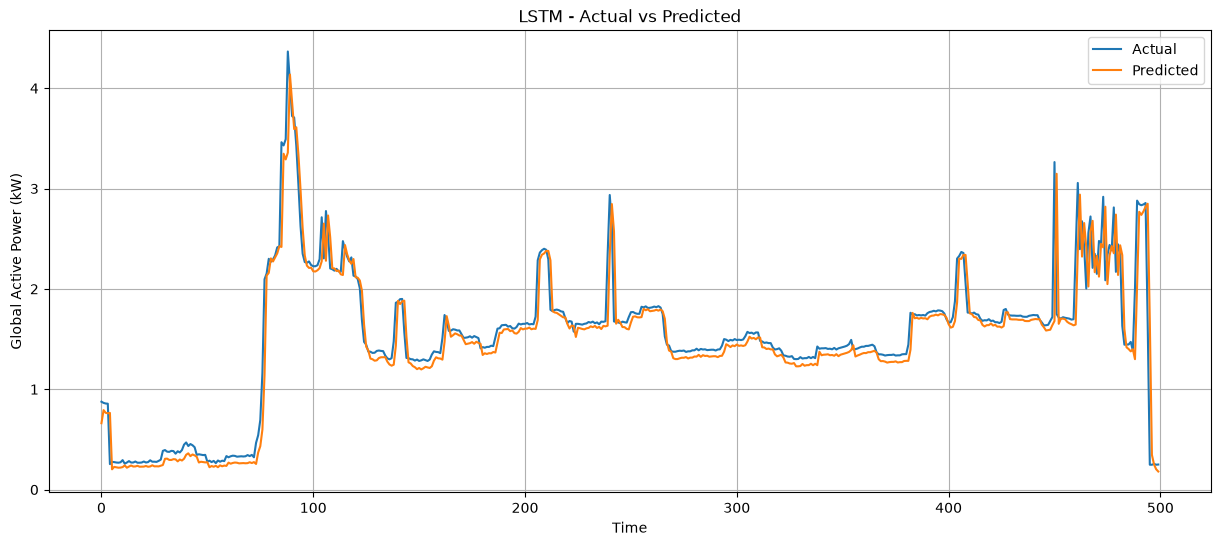

In [27]:
plt.figure(figsize=(15, 6))

plt.plot(
    y_actual[:500],
    label='Actual'
)

plt.plot(
    y_pred[:500],
    label='Predicted'
)

plt.title(
    'LSTM - Actual vs Predicted'
)

plt.xlabel('Time')

plt.ylabel(
    'Global Active Power (kW)'
)

plt.legend()

plt.grid(True)

plt.show()

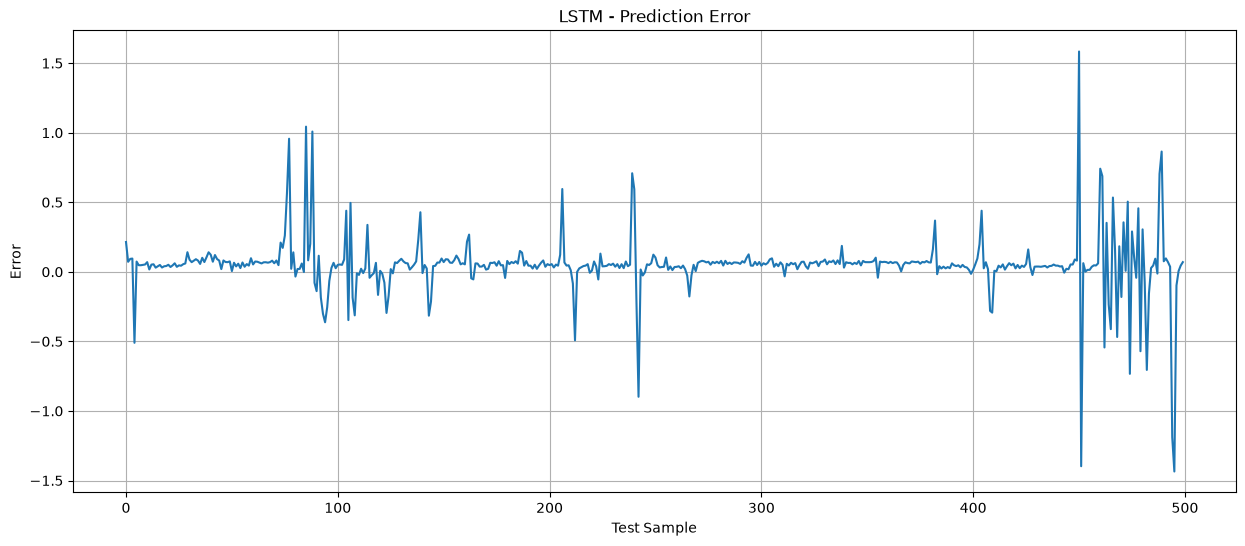

In [28]:
errors = (
    y_actual - y_pred
)

plt.figure(figsize=(15, 6))

plt.plot(
    errors[:500]
)

plt.title(
    'LSTM - Prediction Error'
)

plt.xlabel('Test Sample')

plt.ylabel('Error')

plt.grid(True)

plt.show()

In [29]:
def predict_lstm(index):

    try:

        index = int(index)

        if index < SEQUENCE_LENGTH:
            return (
                f"Index must be at least "
                f"{SEQUENCE_LENGTH}."
            )

        if index >= len(df):
            return (
                f"Index must be less than "
                f"{len(df)}."
            )

        # Get previous 60 power values
        sequence = power[
            index-SEQUENCE_LENGTH:index
        ]

        # Scale
        sequence_scaled = scaler.transform(
            sequence
        )

        # Reshape for LSTM
        X_input = sequence_scaled.reshape(
            1,
            SEQUENCE_LENGTH,
            1
        )

        # Prediction
        prediction_scaled = (
            lstm_model.predict(
                X_input,
                verbose=0
            )
        )

        # Convert back to kW
        prediction = scaler.inverse_transform(
            prediction_scaled
        )[0][0]

        # Actual value
        actual = power[index][0]

        # Datetime
        datetime_value = df[
            'Datetime'
        ].iloc[index]

        return (
            f"Date/Time: {datetime_value}\n\n"
            f"Actual Power: {actual:.4f} kW\n"
            f"Predicted Power: {prediction:.4f} kW\n\n"
            f"Error: {actual - prediction:.4f} kW"
        )

    except Exception as e:

        return f"Error: {str(e)}"

In [30]:
with gr.Blocks(
    title="Smart Grid Power Forecasting - LSTM"
) as demo:

    gr.Markdown(
        """
        # ⚡ Smart Grid Power Forecasting

        ## LSTM Model

        The LSTM uses the previous **60 minutes**
        of household electricity consumption to
        predict the next power consumption value.
        """
    )

    gr.Markdown(
        """
        ### How to use

        Enter an observation index. The system will
        automatically take the previous 60 observations
        and generate the LSTM prediction.
        """
    )

    index_input = gr.Number(
        label="Dataset Observation Index",
        value=10000,
        precision=0
    )

    predict_button = gr.Button(
        "⚡ Predict Power",
        variant="primary"
    )

    output = gr.Textbox(
        label="Prediction Result",
        lines=6
    )

    predict_button.click(
        fn=predict_lstm,
        inputs=index_input,
        outputs=output
    )

demo.launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.
